Fichier trouvé : /kaggle/input/prices/prices.csv
Aperçu des premières lignes :


,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


Shape (nb_lignes, nb_colonnes) : (851264, 7)

Informations sur le DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB

Statistiques descriptives des variables numériques :


,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08



Nombre de valeurs manquantes par colonne :


...


Pourcentage de valeurs manquantes par colonne :


date      0.0
symbol    0.0
open      0.0
close     0.0
low       0.0
high      0.0
volume    0.0
dtype: float64


Période couverte par le dataset : 2010-01-04 00:00:00 -> 2016-12-30 00:00:00
Nombre de dates uniques : 1762

Nombre de symboles (actions) différents : 501

Top 10 des symboles les plus fréquents :


symbol
VTR     1762
VZ      1762
WAT     1762
WBA     1762
WDC     1762
WEC     1762
WFC     1762
WFM     1762
VFC     1762
VIAB    1762
Name: count, dtype: int64

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


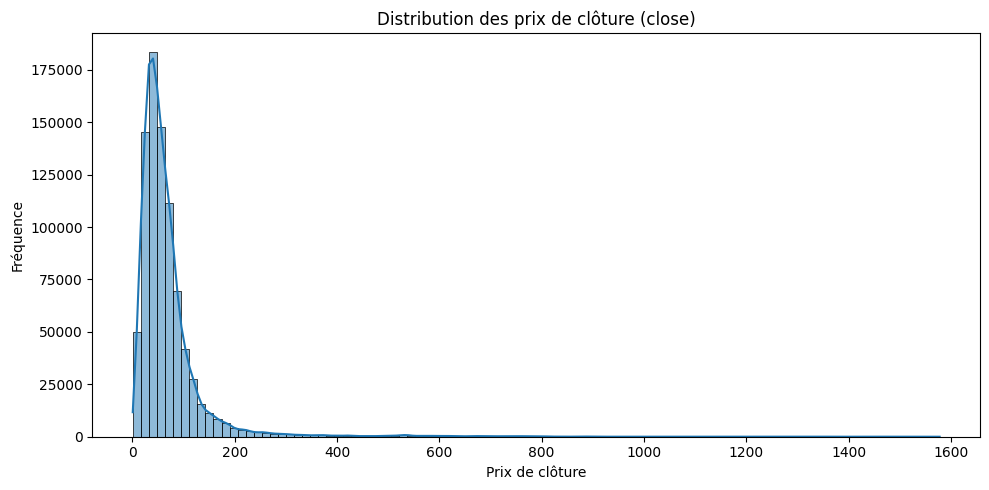

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


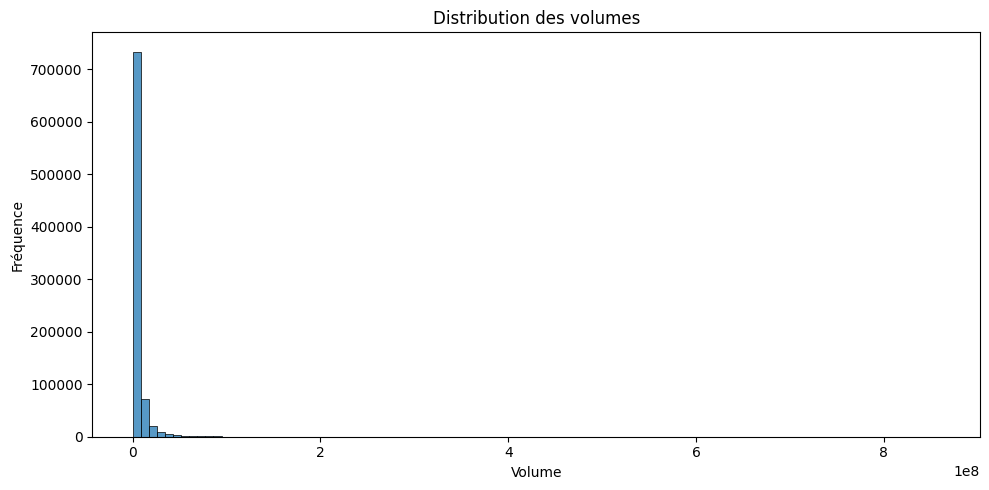


Symbole le plus fréquent sélectionné pour l'analyse temporelle : VTR

Aperçu des données pour le symbole VTR :


,date,symbol,open,close,low,high,volume
690,2010-01-04,VTR,44.200001,43.349998,43.060001,44.619999,1196900.0
1158,2010-01-05,VTR,43.250000,43.560001,42.730000,43.650002,1444600.0
1626,2010-01-06,VTR,43.560001,43.070000,42.830002,43.830002,1980500.0
2094,2010-01-07,VTR,42.939999,43.549999,42.560001,43.700001,2772800.0
2562,2010-01-08,VTR,43.259998,43.070000,42.610001,43.450001,1656000.0


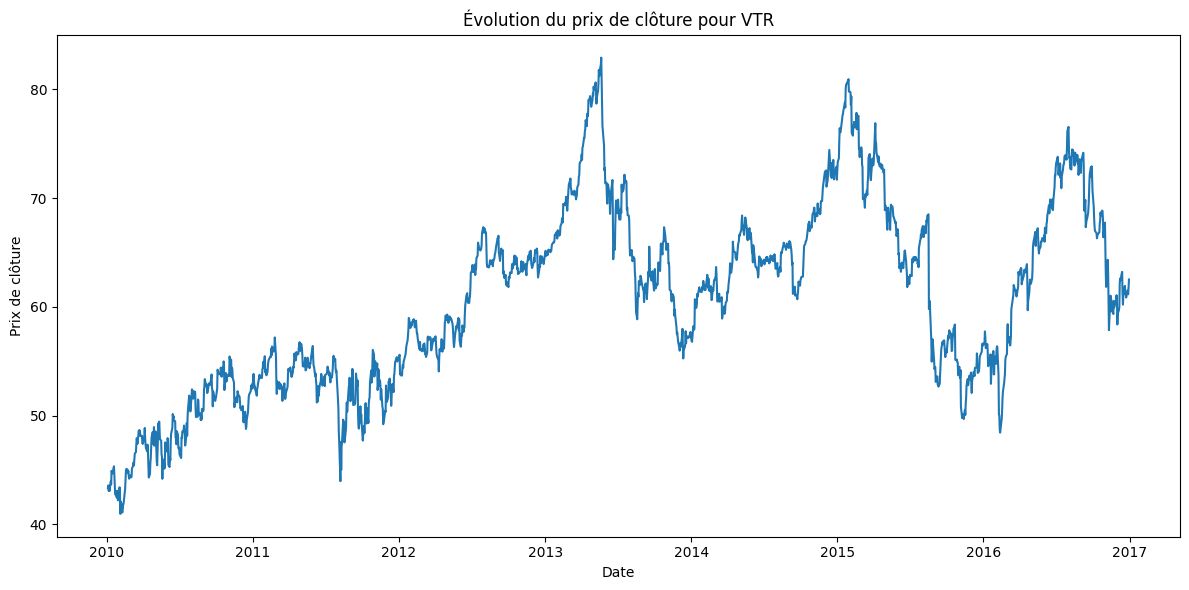

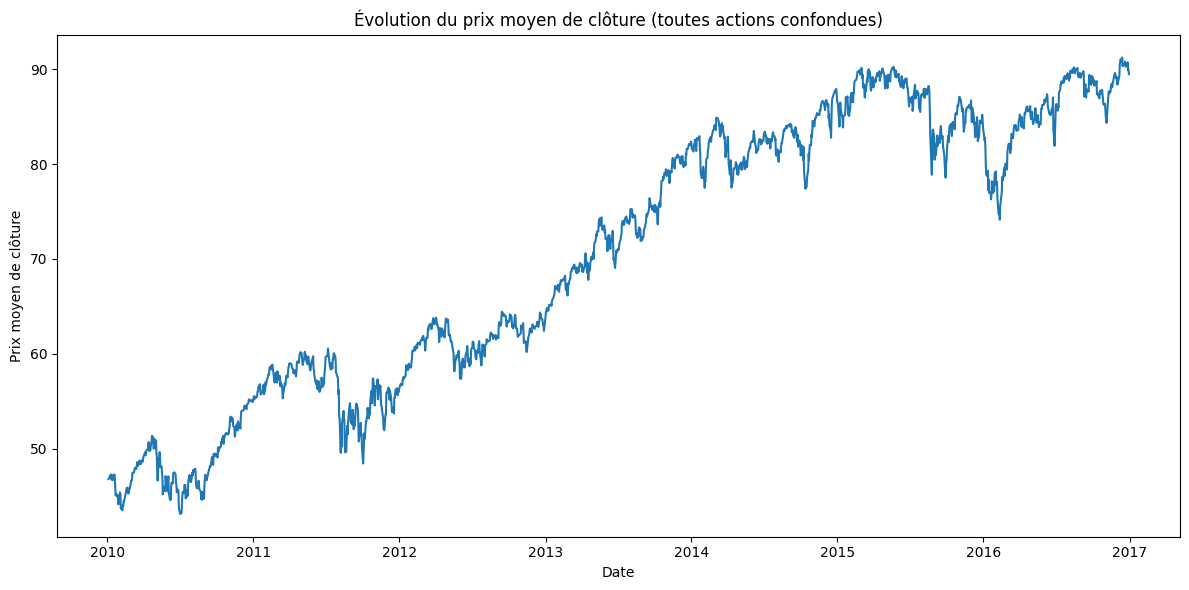

In [4]:
# ==============================
# 1. Import des librairies
# ==============================
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Option pour afficher les graphiques directement dans le notebook
%matplotlib inline

# Améliorer un peu l'affichage des DataFrames
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)

# ==============================
# 2. Localiser et charger prices.csv
# ==============================
# Sur Kaggle, les datasets sont généralement dans /kaggle/input
# Ce bloc permet de vérifier où se trouve le fichier prices.csv

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower() == "prices.csv":
            print("Fichier trouvé :", os.path.join(root, f))

# Après avoir vu le chemin exact dans la sortie précédente,
# remplace le chemin ci-dessous si nécessaire.
# Exemple courant : "/kaggle/input/prices/prices.csv"
prices_path = "/kaggle/input/prices/prices.csv"  # A ADAPTER si besoin

# Chargement du fichier CSV dans un DataFrame pandas
df = pd.read_csv(prices_path)

# ==============================
# 3. Aperçu global du dataset
# ==============================

# Afficher les 5 premières lignes pour voir la structure générale
print("Aperçu des premières lignes :")
display(df.head())

# Taille du dataset : nombre de lignes et de colonnes
print("Shape (nb_lignes, nb_colonnes) :", df.shape)

# Informations sur les types de données et les valeurs non nulles
print("\nInformations sur le DataFrame :")
df.info()

# Statistiques descriptives pour les colonnes numériques
print("\nStatistiques descriptives des variables numériques :")
display(df.describe())

# ==============================
# 4. Gestion / vérification des valeurs manquantes
# ==============================

print("\nNombre de valeurs manquantes par colonne :")
missing_values = df.isna().sum()
display(missing_values)

# Optionnel : calculer le pourcentage de valeurs manquantes
print("\nPourcentage de valeurs manquantes par colonne :")
missing_percent = df.isna().mean() * 100
display(missing_percent)

# ==============================
# 5. Analyse de la dimension temporelle
# ==============================

# Conversion de la colonne 'date' en type datetime
df["date"] = pd.to_datetime(df["date"], format="ISO8601")


# Date minimale et maximale
min_date = df["date"].min()
max_date = df["date"].max()

print(f"\nPériode couverte par le dataset : {min_date} -> {max_date}")

# Nombre de jours uniques
nb_jours_uniques = df["date"].nunique()
print("Nombre de dates uniques :", nb_jours_uniques)

# ==============================
# 6. Analyse des symboles (actions)
# ==============================

# Nombre de symboles différents
nb_symbols = df["symbol"].nunique()
print("\nNombre de symboles (actions) différents :", nb_symbols)

# Top 10 des symboles les plus présents dans le dataset
print("\nTop 10 des symboles les plus fréquents :")
symbol_counts = df["symbol"].value_counts()
display(symbol_counts.head(10))

# ==============================
# 7. Visualisation : distribution des prix de clôture
# ==============================

plt.figure(figsize=(10, 5))
sns.histplot(df["close"], bins=100, kde=True)
plt.title("Distribution des prix de clôture (close)")
plt.xlabel("Prix de clôture")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# ==============================
# 8. Visualisation : distribution des volumes
# ==============================

plt.figure(figsize=(10, 5))
sns.histplot(df["volume"], bins=100, kde=False)
plt.title("Distribution des volumes")
plt.xlabel("Volume")
plt.ylabel("Fréquence")
plt.tight_layout()
plt.show()

# ==============================
# 9. Visualisation temporelle pour un symbole
# ==============================

# On choisit le symbole le plus fréquent dans le dataset
most_frequent_symbol = symbol_counts.idxmax()
print("\nSymbole le plus fréquent sélectionné pour l'analyse temporelle :", most_frequent_symbol)

# Filtrage des données pour ce symbole
df_symbol = df[df["symbol"] == most_frequent_symbol].copy()

# Tri par date pour avoir une série temporelle ordonnée
df_symbol = df_symbol.sort_values("date")

# Affichage des premières lignes pour ce symbole
print(f"\nAperçu des données pour le symbole {most_frequent_symbol} :")
display(df_symbol.head())

# Courbe du prix de clôture au cours du temps pour ce symbole
plt.figure(figsize=(12, 6))
plt.plot(df_symbol["date"], df_symbol["close"])
plt.title(f"Évolution du prix de clôture pour {most_frequent_symbol}")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.tight_layout()
plt.show()

# ==============================
# 10. Exemple : prix moyen de clôture par jour (sur toutes les actions)
# ==============================

# Calcul du prix moyen de clôture par date
daily_mean_close = df.groupby("date")["close"].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(daily_mean_close["date"], daily_mean_close["close"])
plt.title("Évolution du prix moyen de clôture (toutes actions confondues)")
plt.xlabel("Date")
plt.ylabel("Prix moyen de clôture")
plt.tight_layout()
plt.show()


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [9]:
model = StockRegressor().to(device)


In [10]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)


In [11]:
# ============================================================
# 1. Import
# ============================================================
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# ============================================================
# 2. Préparation des données
# ============================================================
features = ["open", "high", "low", "volume"]
target = "close"

X = df[features].values
y = df[target].values.reshape(-1, 1)

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

# Conversion en tenseurs CPU puis GPU ensuite
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

# ============================================================
# 3. Sélection du GPU
# ============================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)

# ============================================================
# 4. Modèle ANN
# ============================================================
class StockRegressor(nn.Module):
    def __init__(self):
        super(StockRegressor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(4, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

model = StockRegressor().to(device)

# Move data to GPU
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)

# ============================================================
# 5. Loss + Optimizer
# ============================================================
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ============================================================
# 6. Training
# ============================================================
epochs = 50

for epoch in range(epochs):
    model.train()

    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{epochs} - Loss = {loss.item():.6f}")

# ============================================================
# 7. Evaluation
# ============================================================
model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_loss = criterion(test_pred, y_test).item()

print("Test Loss (MSE) :", test_loss)


Device utilisé : cuda
Epoch 0/50 - Loss = 0.035535
Epoch 10/50 - Loss = 0.002214
Epoch 20/50 - Loss = 0.003850
Epoch 30/50 - Loss = 0.001921
Epoch 40/50 - Loss = 0.001271
Test Loss (MSE) : 0.0010080968495458364


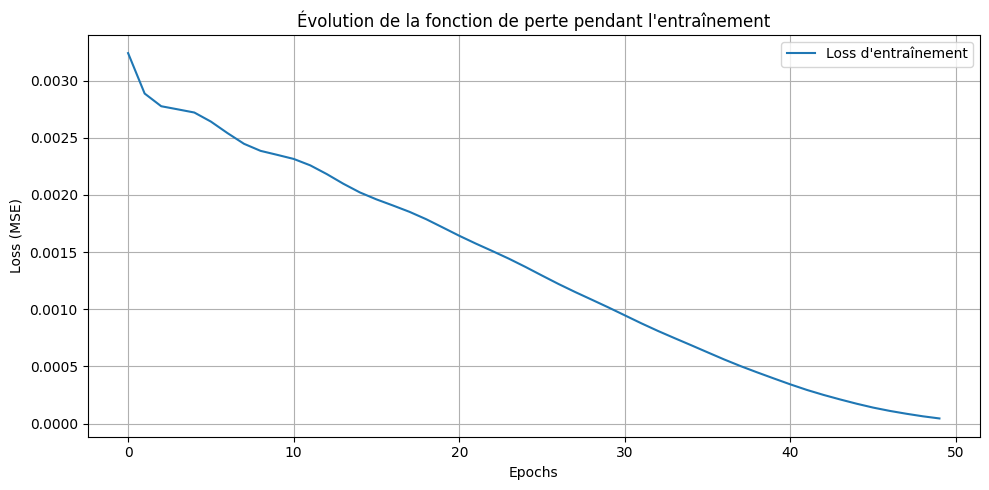

In [12]:
# ============================================================
# Plot de l'évolution de la loss pendant l'entraînement
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot simple de la perte
plt.plot(loss_history, label="Loss d'entraînement")

plt.title("Évolution de la fonction de perte pendant l'entraînement")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


PyTorch version: 2.6.0+cu124
CUDA available: True
Device utilisé : cuda
GPU: Tesla T4
Mémoire disponible: 15.828320256 GB
Dataset chargé : 851,264 lignes, 7 colonnes
        date symbol        open       close         low        high     volume
0 2016-01-05   WLTW  123.430000  125.839996  122.309998  126.250000  2163600.0
1 2016-01-06   WLTW  125.239998  119.980003  119.940002  125.540001  2386400.0
2 2016-01-07   WLTW  116.379997  114.949997  114.930000  119.739998  2489500.0
3 2016-01-08   WLTW  115.480003  116.620003  113.500000  117.440002  2006300.0
4 2016-01-11   WLTW  117.010002  114.970001  114.089996  117.330002  1408600.0


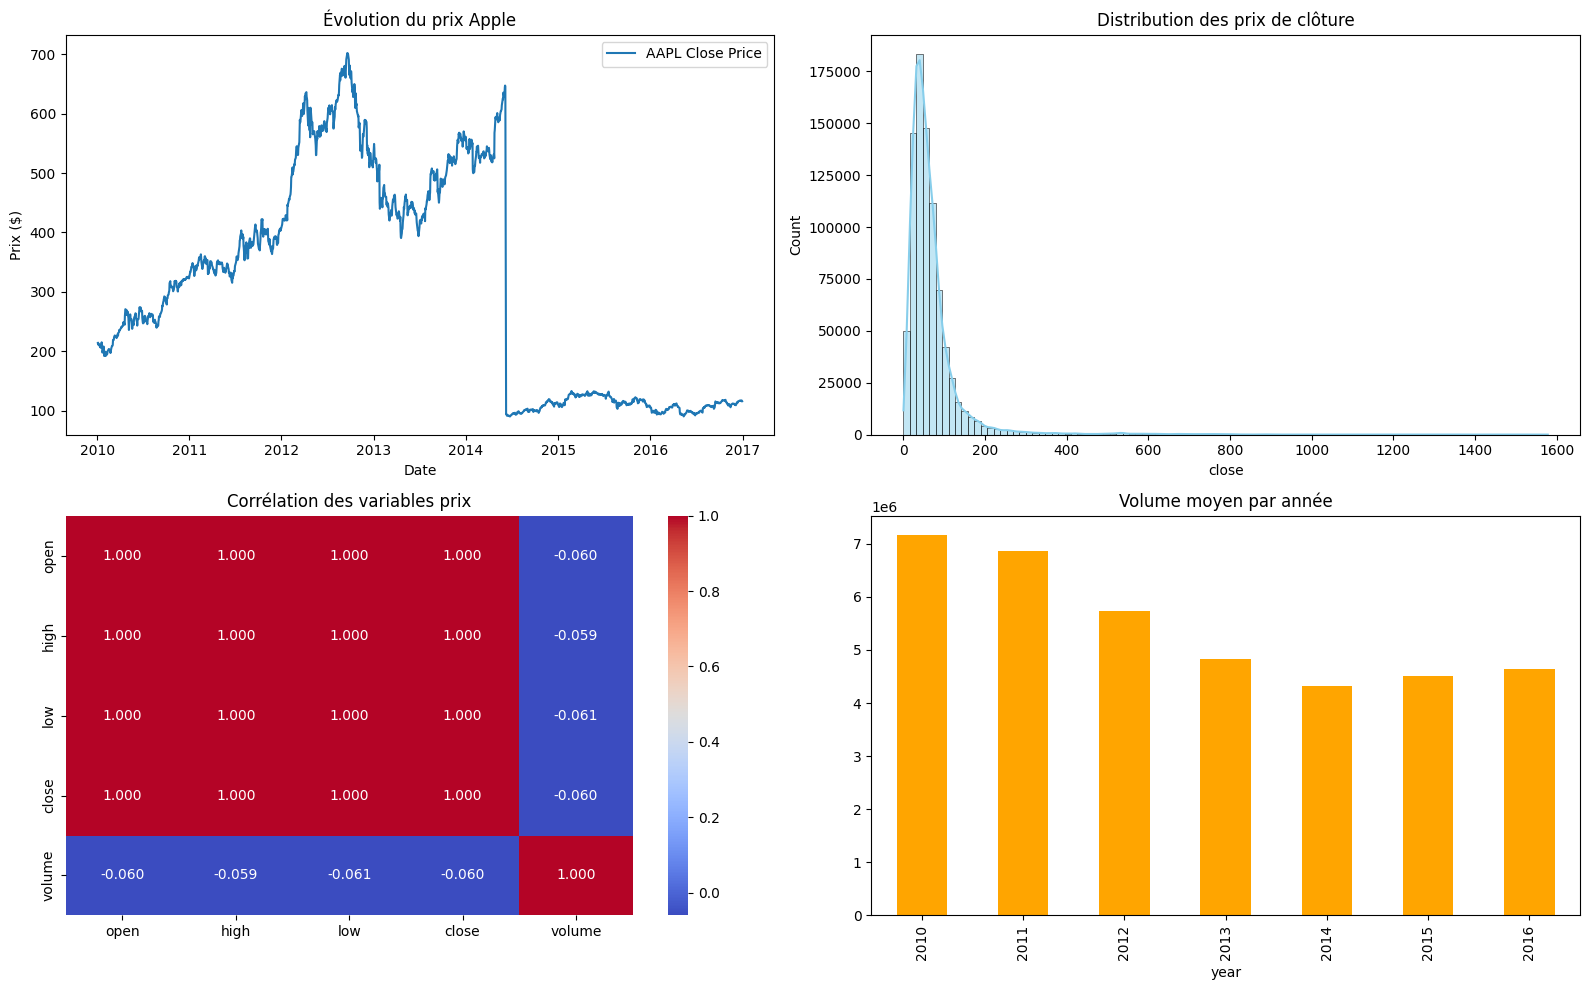


Recherche des meilleurs hyperparamètres...
Testé → {'dropout': 0.2, 'layers': [128, 64, 32], 'lr': 0.001}  →  Test MSE = 105.9627
Testé → {'dropout': 0.2, 'layers': [128, 64, 32], 'lr': 0.0005}  →  Test MSE = 19.8200
Testé → {'dropout': 0.2, 'layers': [128, 64, 32], 'lr': 0.01}  →  Test MSE = 57.5037
Testé → {'dropout': 0.2, 'layers': [256, 128, 64], 'lr': 0.001}  →  Test MSE = 7.5403
Testé → {'dropout': 0.2, 'layers': [256, 128, 64], 'lr': 0.0005}  →  Test MSE = 14.8490
Testé → {'dropout': 0.2, 'layers': [256, 128, 64], 'lr': 0.01}  →  Test MSE = 236.0662
Testé → {'dropout': 0.2, 'layers': [64, 32], 'lr': 0.001}  →  Test MSE = 38.4576
Testé → {'dropout': 0.2, 'layers': [64, 32], 'lr': 0.0005}  →  Test MSE = 15.1370
Testé → {'dropout': 0.2, 'layers': [64, 32], 'lr': 0.01}  →  Test MSE = 66.3248
Testé → {'dropout': 0.3, 'layers': [128, 64, 32], 'lr': 0.001}  →  Test MSE = 31.1807
Testé → {'dropout': 0.3, 'layers': [128, 64, 32], 'lr': 0.0005}  →  Test MSE = 36.1034
Testé → {'dropout': 

In [1]:
# ======================== Atelier 1 (Version adaptée Inra - GPU) ======================== #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ========================================================================================
# GPU Setup
# ========================================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device utilisé :", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("Mémoire disponible:", torch.cuda.get_device_properties(0).total_memory / 1e9, "GB")

# ========================================================================================
# CHARGEMENT DU DATASET KAGGLE
# ========================================================================================
# Chemin Kaggle correct
df_prices = pd.read_csv("/kaggle/input/prices/prices.csv")

# Conversion flexible de la date (supporte plusieurs formats)
df_prices["date"] = pd.to_datetime(df_prices["date"], format="mixed")

print(f"Dataset chargé : {df_prices.shape[0]:,} lignes, {df_prices.shape[1]} colonnes")
print(df_prices.head())

# ========================================================================================
# PARTIE 1 – EDA
# ========================================================================================

plt.figure(figsize=(16, 10))

# AAPL Close Price
plt.subplot(2, 2, 1)
aapl = df_prices[df_prices['symbol'] == 'AAPL']
plt.plot(aapl['date'], aapl['close'], label='AAPL Close Price')
plt.title('Évolution du prix Apple')
plt.xlabel('Date')
plt.ylabel('Prix ($)')
plt.legend()

# Distribution close
plt.subplot(2, 2, 2)
sns.histplot(df_prices['close'], bins=100, kde=True, color='skyblue')
plt.title('Distribution des prix de clôture')

# Corrélation
plt.subplot(2, 2, 3)
corr = df_prices[['open', 'high', 'low', 'close', 'volume']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Corrélation des variables prix')

# Volume moyen par année
plt.subplot(2, 2, 4)
df_prices['year'] = df_prices['date'].dt.year
df_prices.groupby('year')['volume'].mean().plot(kind='bar', color='orange')
plt.title('Volume moyen par année')

plt.tight_layout()
plt.show()

# ========================================================================================
# PARTIE 2 – Préparation des données pour la régression
# ========================================================================================

features = ['open', 'high', 'low', 'volume']
X = df_prices[features].values
y = df_prices['close'].values

# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Normalisation
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Conversion GPU
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
y_test_t = torch.FloatTensor(y_test).reshape(-1, 1).to(device)

# DataLoader CPU → GPU pendant l'entraînement
train_dataset_reg = list(zip(torch.FloatTensor(X_train), 
                             torch.FloatTensor(y_train).reshape(-1, 1)))
train_loader_reg = DataLoader(train_dataset_reg, batch_size=256, shuffle=True)

# ========================================================================================
# PARTIE 3 – Modèle ANN 
# ========================================================================================

class Regressor(nn.Module):
    def __init__(self, layers=[128, 64, 32], dropout=0.3):
        super().__init__()
        net = []
        prev = 4
        for h in layers:
            net += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        net.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*net)

    def forward(self, x):
        return self.net(x)

# ========================================================================================
# PARTIE 4 – Fonction d'entraînement (GPU)
# ========================================================================================

def train_reg(model, epochs=80, lr=0.001, wd=0):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    crit = nn.MSELoss()
    train_l, test_l = [], []

    for epoch in range(epochs):
        model.train()
        loss_sum = 0

        for xb, yb in train_loader_reg:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            pred = model(xb)
            loss = crit(pred, yb)
            loss.backward()
            opt.step()
            loss_sum += loss.item()

        # Évaluation test
        model.eval()
        with torch.no_grad():
            test_loss = crit(model(X_test_t), y_test_t).item()

        train_l.append(loss_sum / len(train_loader_reg))
        test_l.append(test_loss)

    return train_l, test_l

# ========================================================================================
# PARTIE 5 – GridSearch manuel (gardé)
# ========================================================================================

print("\nRecherche des meilleurs hyperparamètres...")

grid = ParameterGrid({
    'layers': [[128, 64, 32], [256, 128, 64], [64, 32]],
    'lr': [0.001, 0.0005, 0.01],
    'dropout': [0.2, 0.3, 0.4]
})

best_mse = np.inf
best_params = None
best_model_reg = None

for params in grid:
    model = Regressor(layers=params['layers'], dropout=params['dropout'])
    _, test_losses = train_reg(model, epochs=50, lr=params['lr'])
    final_mse = test_losses[-1]
    print(f"Testé → {params}  →  Test MSE = {final_mse:.4f}")

    if final_mse < best_mse:
        best_mse = final_mse
        best_params = params
        best_model_reg = model

print(f"\nMeilleur modèle → {best_params} | Test MSE = {best_mse:.4f}")

# ========================================


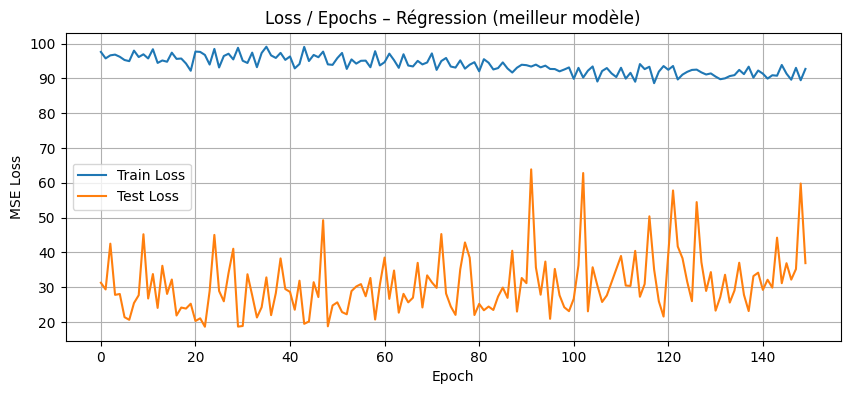

In [5]:
# ========================================================================================
# PARTIE 6 – Entraînement final du meilleur modèle
# ========================================================================================

train_loss_final, test_loss_final = train_reg(
    best_model_reg, epochs=150, lr=best_params['lr'], wd=1e-5
)

plt.figure(figsize=(10, 4))
plt.plot(train_loss_final, label='Train Loss')
plt.plot(test_loss_final, label='Test Loss')
plt.title('Loss / Epochs – Régression (meilleur modèle)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid()
plt.show()

In [6]:
# ========================================================================================
# PARTIE 7 – Évaluation finale
# ========================================================================================

with torch.no_grad():
    pred_reg = best_model_reg(X_test_t).cpu().numpy().flatten()

y_test_cpu = y_test_t.cpu().numpy().flatten()

print("RMSE =", mean_squared_error(y_test_cpu, pred_reg, squared=False))
print("R²   =", r2_score(y_test_cpu, pred_reg))


RMSE = 6.074992
R²   = 0.9947130065443707


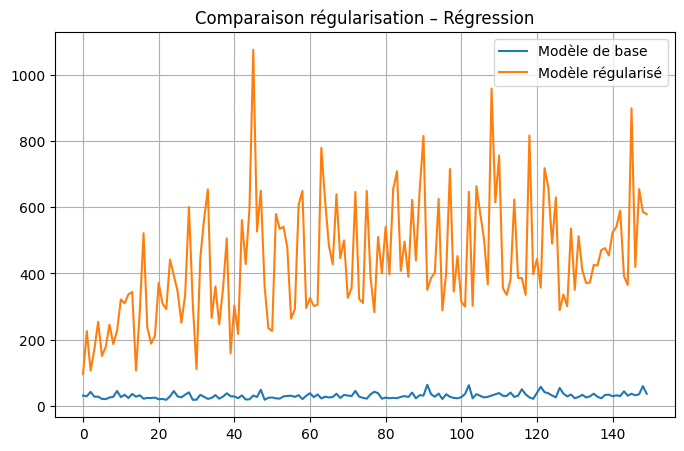

In [7]:
# ========================================================================================
# PARTIE 8 – Modèle avec régularisation avancée (BatchNorm+Dropout)
# ========================================================================================

class RegReg(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, 64), nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

reg_model = RegReg()
_, test_reg = train_reg(reg_model, epochs=150, lr=0.0005, wd=1e-4)

plt.figure(figsize=(8, 5))
plt.plot(test_loss_final, label='Modèle de base')
plt.plot(test_reg, label='Modèle régularisé')
plt.title('Comparaison régularisation – Régression')
plt.legend()
plt.grid()
plt.show()